In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# Paths
path_eq_MD = "NSL_SIMULATOR/OUTPUT/EQUILIBRATION/MD/"
path_MD = "NSL_SIMULATOR/OUTPUT/EX_7_2/MD/"
path_eq_MC = "NSL_SIMULATOR/OUTPUT/EQUILIBRATION/MC/"
path_MC = "NSL_SIMULATOR/OUTPUT/EX_7_2/MC/"

path_MD_eq4 = "NSL_SIMULATOR/OUTPUT/EX_7_4/EQUILIBRATION/MD/"
path_MC_eq4 = "NSL_SIMULATOR/OUTPUT/EX_7_4/EQUILIBRATION/MC/"
path_MD4 = "NSL_SIMULATOR/OUTPUT/EX_7_4/MD/"
path_MC4 = "NSL_SIMULATOR/OUTPUT/EX_7_4/MC/"

# Theoretical Background

In this exercise, we simulate a fluid composed of 108 Argon particles interacting via a Lennard-Jones (LJ) potential. The system is studied in the liquid phase under the following thermodynamic conditions: 
- reduced density $\rho^\star = 0.8$; 
- reduced temperature $T^\star = 1.1$; 
- cut-off radius $r_c = 2.5$. 

To correctly account for the spherical truncation of the long-range potential, analytical tail corrections are applied to both the potential energy and the pressure.

The simulation is performed using two distinct sampling algorithms: **Monte Carlo (MC)** in the canonical (NVT) ensemble and **Molecular Dynamics (MD)** in the microcanonical (NVE) ensemble. 

The first part of this exercise focuses on studying the autocorrelation time of the instantaneous measurements produced by both methods. This step is crucial for determining the optimal block length required to obtain statistically independent measurements of our macroscopic observables. In the second part, we compute and plot the potential energy per particle, the pressure, and the radial distribution function $g(r)$ for the equilibrated system, utilizing the optimal block length derived from our autocorrelation analysis.

## Autocorrelation

Both Markov Chain Monte Carlo (MCMC) and Verlet integration intrinsically generate sequences of highly correlated states: the former due to local stochastic proposal moves, and the latter due to the integration of deterministic equations of motion. To correctly apply the Data Blocking technique, we must first determine the "memory time" (or correlation time) of the system.  

To this end, we compute the autocorrelation function $\chi(\tau)$ for the instantaneous potential energy per particle $U/N$ as a function of the time lag $\tau$:

$$\chi(\tau) = \frac{\frac{1}{t_{max}-\tau}\sum_{t'=0}^{t_{max}-\tau} m(t')m(t'+\tau) - \left[\frac{1}{t_{max}-\tau}\sum_{t'=0}^{t_{max}-\tau} m(t')\right] \left[\frac{1}{t_{max}-\tau}\sum_{t'=0}^{t_{max}-\tau} m(t'+\tau)\right]}{\frac{1}{t_{max}}\sum_{t'=0}^{t_{max}} m^2(t') - \left[\frac{1}{t_{max}}\sum_{t'=0}^{t_{max}} m(t')\right]^2}$$

While it might seem computationally faster to subtract the global mean $\langle m \rangle$ (computed over the entire dataset of size $t_{max}$) from all terms, the formula above adopts a more rigorous approach. In the numerator, all temporal averages are strictly evaluated using the exact same overlapping subset of data of length $t_{max}-t$. 

Evaluating the decay of this function helps us understand how large our blocks must be to ensure that we are averaging statistically independent samples. Given the complex, many-body nature of the Lennard-Jones fluid, this autocorrelation function does not necessarily follow a simple exponential decay, but it effectively bounds the time scale over which the system loses memory of its initial configuration.

In [3]:
# Function to compute autocorrelation function given a time lag
def autocorrelation(data, tau):
    if tau >= len(data):
        raise ValueError("Autocorrelation time tau must be less than the maximum time tmax")
        
    t_max = len(data)

    # data[:t_max - tau]: all data up to t_max - tau
    # data[tau:]: all data from tau to t_max

    first_term = np.mean(data[:t_max - tau] * data[tau:])
    second_term = np.mean(data[:t_max - tau]) * np.mean(data[tau:])
    
    numerator = first_term - second_term
    
    return numerator / np.var(data)


# Function for exponential decay fit: in the following I show that this function
# is not suitable to fit the autocorrelation curves
def exponential_decay(tau, tau_c):
    return np.exp(-tau / tau_c)

# Exercise 7.1

## Tail Corrections
To account for the potential energy and pressure neglected due to the spherical truncation of the potential at $r_c$, we implemented analytical tail corrections. Assuming $g(r) \approx 1$ for $r > r_c$, these corrections in Lennard-Jones reduced units (with $\epsilon=1$ and $\sigma=1$) are defined as:

- **Potential Energy:** $$\frac{\langle V \rangle _{tail}}{N} = 8\pi\rho \left[ \frac{1}{9 r_c^9} - \frac{1}{3 r_c^3} \right]$$

- **Pressure:** $$\langle P \rangle _{tail} = \frac{\langle w_{LJ} \rangle _{tail}}{3V} = 32\pi\rho \left[ \frac{1}{9 r_c^9} - \frac{1}{6 r_c^3} \right]$$
where $w_{LJ}$ is the virial of the Lennard-Jones potential.

# Exercise 7.2

## Molecular Dynamics (NVE)

### MD Equilibration

Before proceeding with data acquisition, the system must reach thermodynamic equilibrium to eliminate any bias introduced by the artificial initial state. The starting configuration is a perfect FCC lattice, originally contained in `NSL_SIMULATOR/INPUT/CONFIG/config.fcc`, which was copied into `NSL_SIMULATOR/INPUT/CONFIG/config.xyz`.

In the NVE (microcanonical) ensemble, Molecular Dynamics conserves the total energy, meaning the kinetic energy, and consequently the instantaneous temperature, goes through a transient phase before starting to fluctuate around its equilibrium value. Our goal was to simulate the liquid phase at a target equilibrium temperature of $T^\star \approx 1.1$. To account for the initial drop in temperature as the crystalline structure melts and the potential energy increases, several initial temperatures were tested. It was empirically found that setting an initial temperature of $T_{start} = 1.95$ allows the system to thermalize correctly around the desired target.

The equilibration simulation was performed using the following input parameters:

| Parameter | Value |
| :--- | :--- |
| **SIMULATION_TYPE** | `0` |
| **RESTART** | `0` |
| **TEMP** | `1.95` |
| **NPART** | `108` | 
| **RHO** | `0.8` |
| **R_CUT** | `2.5` |
| **DELTA** | `0.001` |
| **NBLOCKS** | `10000` |
| **NSTEPS** | `1` |

By setting `NSTEPS = 1` and `NBLOCKS = 10000`, the Data Blocking method effectively acts as a direct logger, providing $10^4$ instantaneous values for the observables of interest. During this phase, we recorded the `POTENTIAL_ENERGY`, `KINETIC_ENERGY`, `TEMPERATURE` and `PRESSURE`. 

The following plots display the instantaneous values of the four measured quantities as a function of the simulation steps. To estimate the final equilibration temperature, I computed the average over the last 6000 steps, a regime where the system has definitively lost its initial transient behavior and properly equilibrated.

In [4]:
_, temp_MD_eq, _, _ = np.loadtxt(path_eq_MD + "temperature.dat", unpack=True)

            Equilibrium temperature T* = 1.1


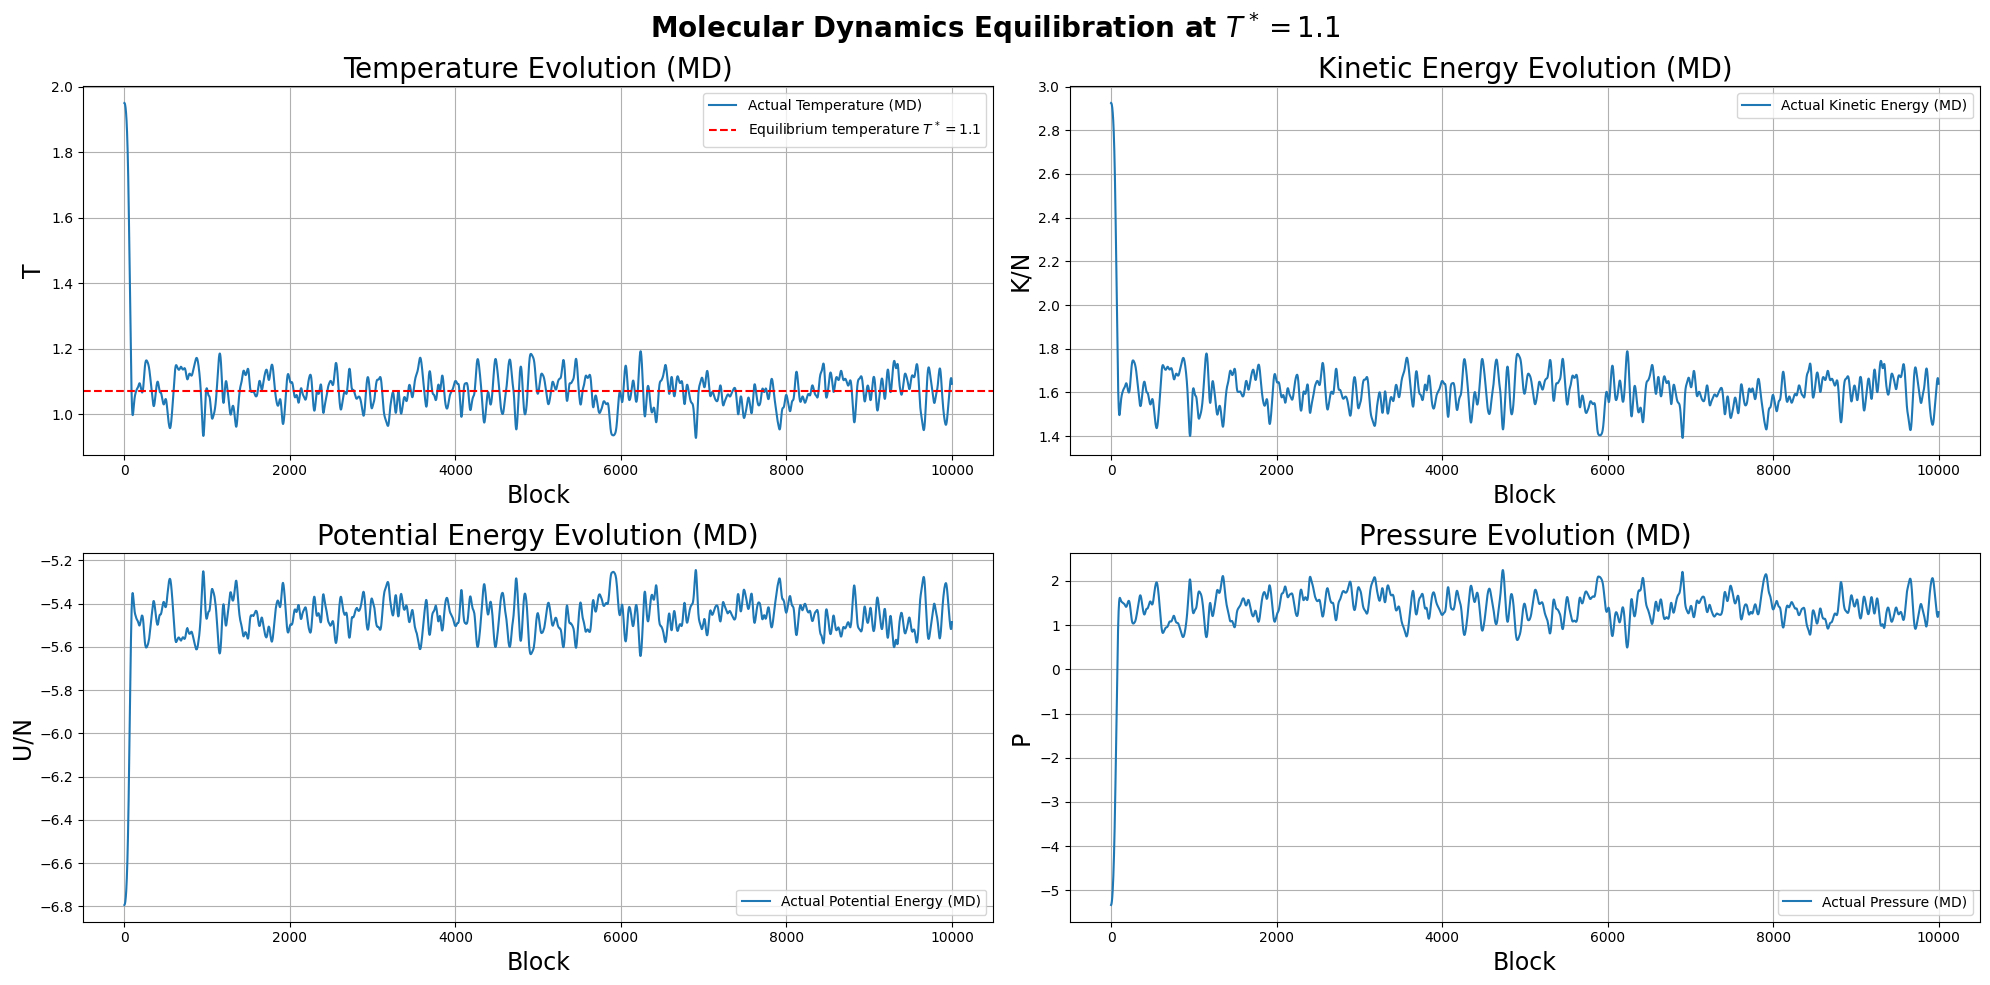

In [5]:
equilibrium_T = np.mean(temp_MD_eq[-6000:])
print("="*60)
print(f"            Equilibrium temperature T* = {equilibrium_T:.1f}")
print("="*60)

observables = [
        {'prefix': 'temperature', 'title': 'Temperature Evolution (MD)', 'ylab': 'T', 'label': 'Actual Temperature (MD)'},
        {'prefix': 'kinetic_energy', 'title': 'Kinetic Energy Evolution (MD)', 'ylab': 'K/N', 'label': 'Actual Kinetic Energy (MD)'},
        {'prefix': 'potential_energy', 'title': 'Potential Energy Evolution (MD)', 'ylab': 'U/N', 'label': 'Actual Potential Energy (MD)'},
        {'prefix': 'pressure', 'title': 'Pressure Evolution (MD)',   'ylab': 'P', 'label': 'Actual Pressure (MD)'}
    ]

fig, axs = plt.subplots(2, 2, figsize=(20, 10))
fig.suptitle(f"Molecular Dynamics Equilibration at $T^*={equilibrium_T:.1f}$", fontsize=20, fontweight='bold')

for obs, ax, k in zip(observables, axs.flatten(), range(len(observables))):

    block, data, _, _ = np.loadtxt(path_eq_MD + obs['prefix'] + ".dat", unpack=True)

    ax.plot(block, data, label=obs['label'])
    ax.set_xlabel("Block", fontsize=17)
    ax.set_ylabel(obs['ylab'], fontsize=17)
    ax.set_title(obs['title'], fontsize=20)
    ax.grid()

    if k==0:
        ax.axhline(equilibrium_T, c='red', linestyle='--', label=f'Equilibrium temperature $T^* = ${equilibrium_T:.1f}')

    ax.legend()

plt.tight_layout()
plt.show()

### Molecular Dynamics Run and Autocorrelation

To perform the run on the equilibrated system, I explicitly mapped the final spatial configurations from the equilibration phase to the new input setup. Specifically, I copied `OUTPUT/CONFIG/config.xyz` into `INPUT/CONFIG/config.xyz` (representing the positions at time $t$) and `OUTPUT/CONFIG/conf-1.xyz` into `INPUT/CONFIG/conf-1.xyz` (representing the positions at time $t-dt$).

By setting `RESTART = 1` in the `input.dat` file, I ensured that the Verlet algorithm bypasses the random generation of Maxwell-Boltzmann velocities. Instead, it computes the next integration step directly from these two exact spatial configurations, seamlessly preserving the true dynamical trajectory and the thermal equilibrium I had just achieved.

For this data acquisition phase, I adjusted the simulation parameters to $5 \times 10^5$ blocks with 1 step per block in order to collect instantaneous values. To optimize computational time, I only recorded the potential energy per particle $U/N$.

Using these instantaneous measurements, I computed the time autocorrelation function $\chi(\tau)$. The results are displayed in the plots below: the left panel shows the decay on a linear scale, while the right panel uses a logarithmic scale for the $y$-axis to better highlight the behavior of the tail.

In [6]:
_, potential_energy_MD, _, _ = np.loadtxt(path_MD + "potential_energy_1.dat", unpack=True)

In [7]:
tau = np.arange(0, 1000, 1)
autocorr_values = [autocorrelation(potential_energy_MD, t) for t in tau]

# Perform the exponential fit knowing it is going to fail
popt, pcov = curve_fit(exponential_decay, tau, autocorr_values)
tau_c = popt[0]

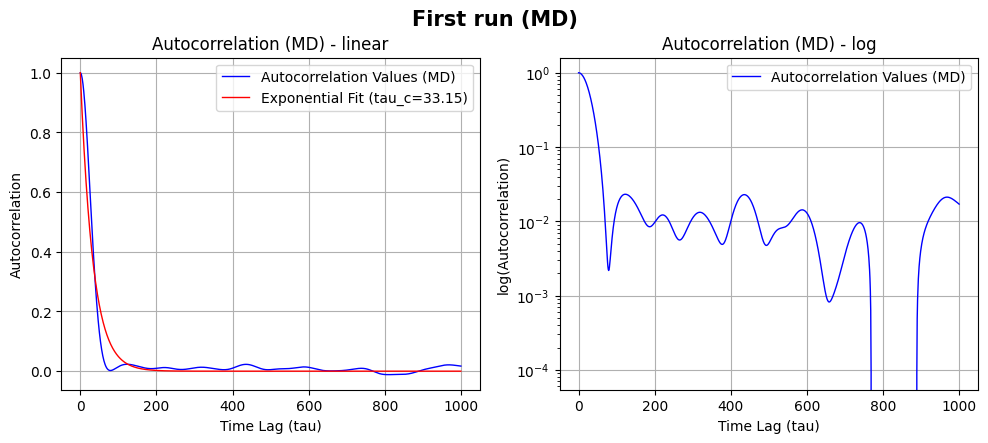

In [8]:
plt.figure(figsize=(10, 12))

plt.suptitle('First run (MD)', fontsize=15, fontweight='bold')

plt.subplot(3, 2, 1)
plt.plot(tau, autocorr_values, color='blue', linewidth=1, label="Autocorrelation Values (MD)")
plt.plot(tau, exponential_decay(tau, tau_c), color='red', linewidth=1, label=f"Exponential Fit (tau_c={tau_c:.2f})")
plt.xlabel("Time Lag (tau)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation (MD) - linear")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(tau, autocorr_values, color='blue', linewidth=1, label="Autocorrelation Values (MD)")
#plt.plot(tau, exponential_decay(tau, tau_c), color='red', linewidth=1, label=f"Exponential Fit (tau_c={tau_c:.2f})")
plt.yscale('log')
plt.xlabel("Time Lag (tau)")
plt.ylabel("log(Autocorrelation)")
plt.title("Autocorrelation (MD) - log")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

As shown in the linear plots, a simple exponential fit fails to accurately describe the autocorrelation decay in our system. This is partially due to the intrinsic complexity of the many-body Lennard-Jones fluid and its non-trivial interaction potential. 

More importantly, the Molecular Dynamics algorithm does not explore phase space via a stochastic random walk (unlike Monte Carlo methods). Instead, it generates a trajectory by deterministically solving Hamilton's equations of motion. Because the dynamics are deterministic, every state is strictly theoretically correlated with all its preceding states. Therefore, we can only speak of "uncorrelated" configurations in a practical, statistical sense: as time progresses, the highly chaotic nature of the liquid's dynamics causes initially close trajectories to diverge rapidly, making the current state statistically independent from the initial one.

Observing the logarithmic plot of the first run, the autocorrelation rapidly drops but then exhibits a peculiar peak around $\tau \approx 900$ steps. To investigate whether this represents a genuine physical "memory comeback" (such as a pressure wave traversing the periodic boundaries of our small simulation box) or merely a statistical coincidence, I performed a second, independent run of $5 \times 10^5$ steps, starting from the final configuration of the first run. 

In [9]:
_, potential_energy_MD_2, _, _ = np.loadtxt(path_MD + "potential_energy_2.dat", unpack=True)

In [10]:
tau = np.arange(0, 1000, 1)
autocorr_values = [autocorrelation(potential_energy_MD_2, t) for t in tau]

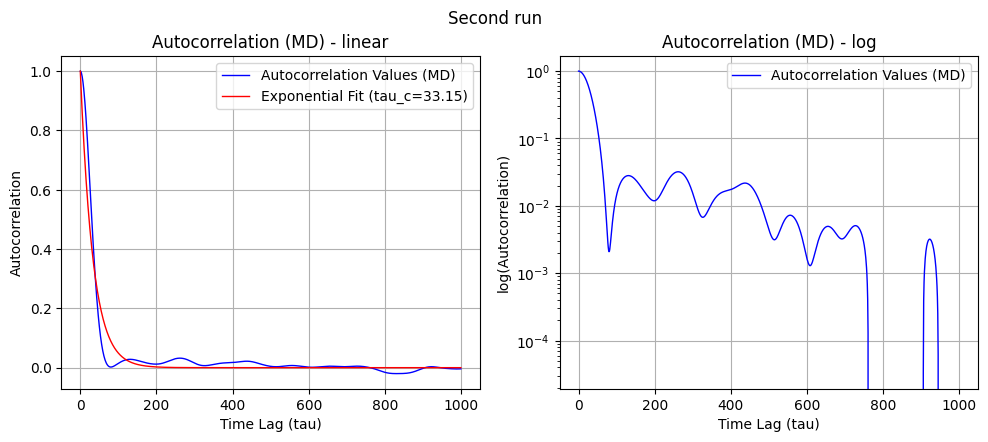

In [11]:
plt.figure(figsize=(10, 12))

plt.suptitle('Second run')

plt.subplot(3, 2, 1)
plt.plot(tau, autocorr_values, color='blue', linewidth=1, label="Autocorrelation Values (MD)")
plt.plot(tau, exponential_decay(tau, tau_c), color='red', linewidth=1, label=f"Exponential Fit (tau_c={tau_c:.2f})")
plt.xlabel("Time Lag (tau)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation (MD) - linear")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(tau, autocorr_values, color='blue', linewidth=1, label="Autocorrelation Values (MD)")
#plt.plot(tau, exponential_decay(tau, tau_c), color='red', linewidth=1, label=f"Exponential Fit (tau_c={tau_c:.2f})")
plt.yscale('log')
plt.xlabel("Time Lag (tau)")
plt.ylabel("log(Autocorrelation)")
plt.title("Autocorrelation (MD) - log")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The plots from the second run (displayed above) show that while a strict, identical periodicity is not perfectly reproduced, a similar peak arises in a roughly comparable position. Because of this, the hypothesis of a weak underlying recurrence, likely a finite-size effect of the simulation box, cannot be completely excluded. 

However, it is crucial to note that the magnitude of this residual correlation is extremely small (on the order of $10^{-2}$ or less). Therefore, for the practical purposes of Data Blocking in this exercise, I can safely establish that after $1000$ steps, the configurations are effectively "uncorrelated". Consequently, using a block length $L \ge 10000$ will comfortably guarantee independent measurements.

## Monte Carlo (NVT)

### MC Equilibration

Similarly to the Molecular Dynamics case, I first needed to equilibrate the system to melt the initial FCC crystalline structure (copied from `NSL_SIMULATOR/INPUT/CONFIG/config.fcc` to `config.xyz`). However, since the Monte Carlo algorithm operates in the canonical (NVT) ensemble, the temperature is not an observable that fluctuates and equilibrates over time; instead, it is a rigidly fixed input parameter ($T^\star = 1.1$) that determines the Metropolis acceptance probability.

I ran the equilibration simulation using the following parameters in `input.dat`. For this phase, I only recorded the instantaneous potential energy per particle and the progressive acceptance rate.

| Parameter | Value |
| :--- | :--- |
| **SIMULATION_TYPE** | `1` |
| **RESTART** | `0` |
| **TEMP** | `1.1` |
| **NPART** | `108` | 
| **RHO** | `0.8` |
| **R_CUT** | `2.5` |
| **DELTA** | `0.1` |
| **NBLOCKS** | `10000` |
| **NSTEPS** | `1` |

In a Monte Carlo simulation, the `DELTA` parameter dictates the maximum displacement amplitude of the random moves proposed to the particles. A well-optimized Metropolis algorithm should maintain an acceptance rate of roughly $50\%$ to ensure an efficient exploration of the phase space without getting stuck or rejecting too many moves. With the choice of `DELTA = 0.1`, we can observe that the progressive acceptance rate indeed converges smoothly to $\sim 50\%$.

In the plots below, I show the instantaneous values of the potential energy and the progressive acceptance rate. From the potential energy plot, it is clear that after $10^4$ steps the system has successfully lost its initial crystalline order and reached thermodynamic equilibrium.

In [12]:
_, acceptance_MC_eq = np.loadtxt(path_eq_MC + "acceptance.dat", unpack=True)
_, potential_energy_MC_eq, _, _ = np.loadtxt(path_eq_MC + "potential_energy.dat", unpack=True)

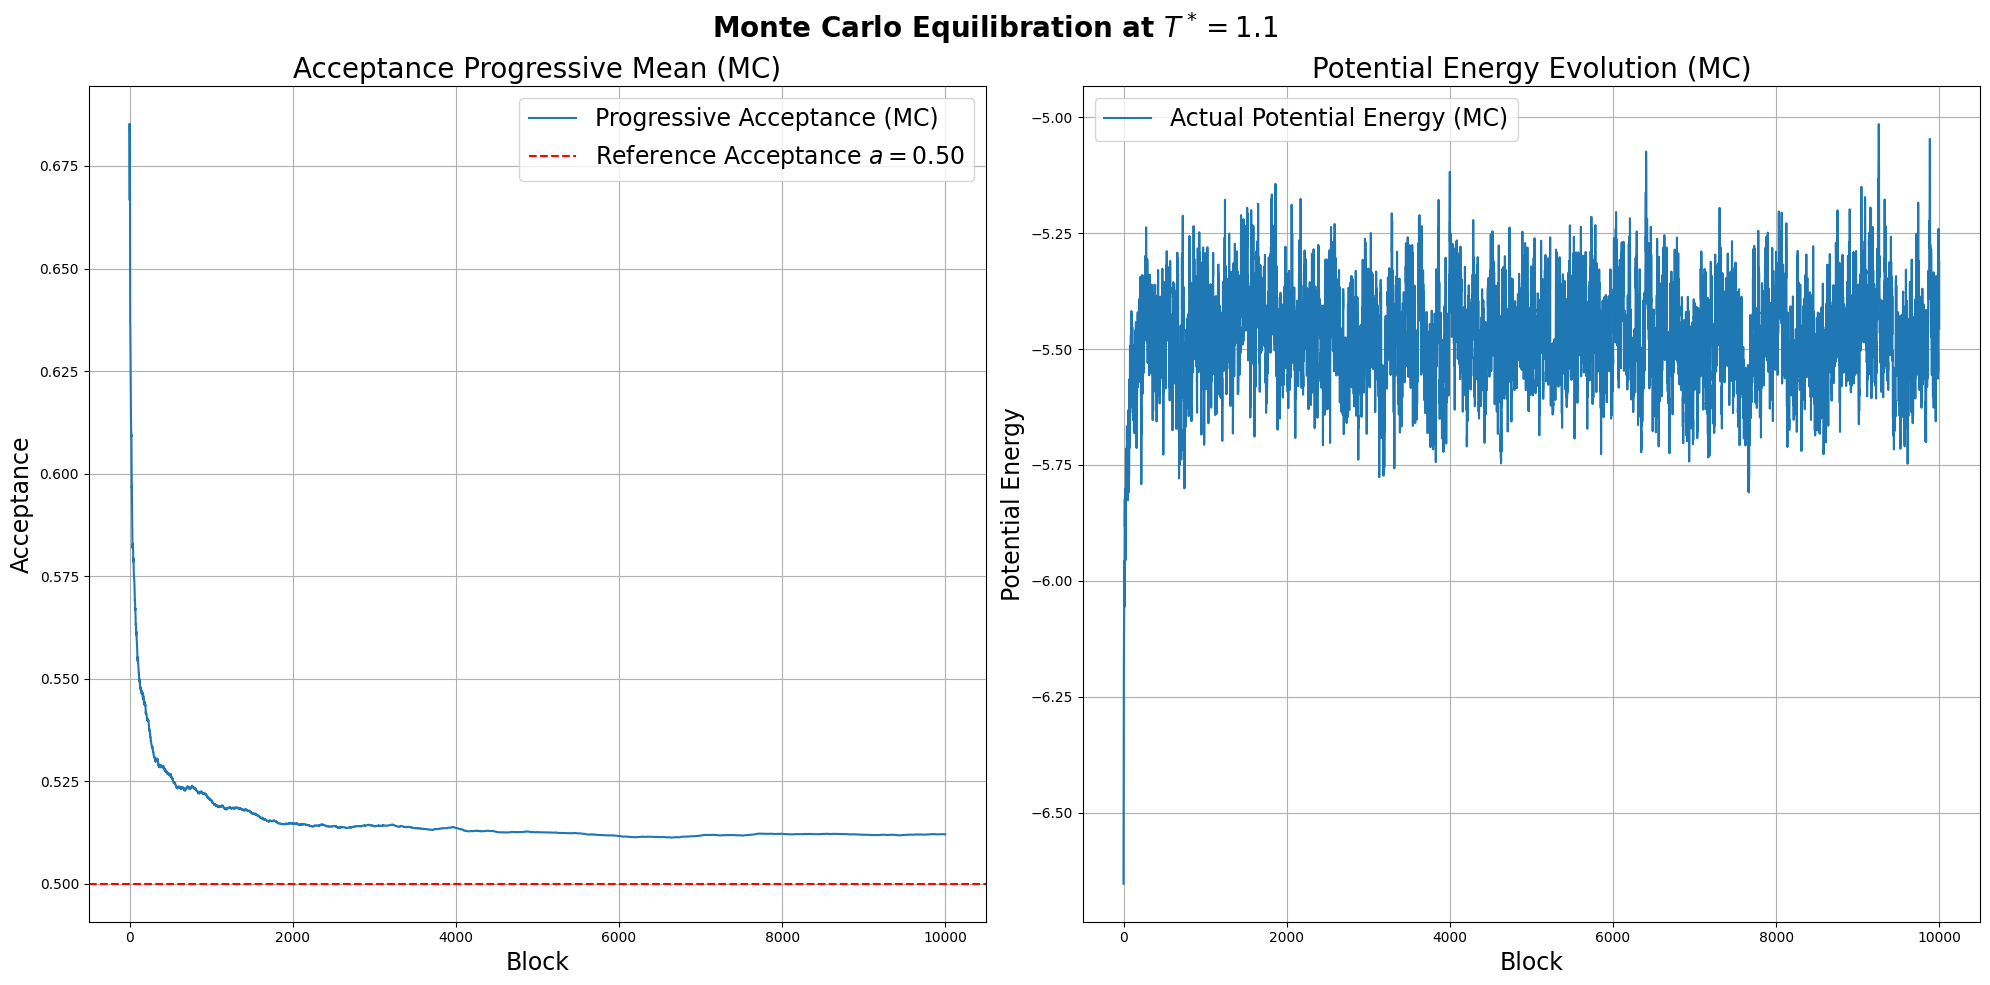

In [13]:
reference_a = 0.50
T_star = 1.1

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle(f"Monte Carlo Equilibration at $T^* = {T_star}$", fontsize=20, fontweight='bold')

axs[0].plot(acceptance_MC_eq, label="Progressive Acceptance (MC)")
axs[0].axhline(reference_a, c='red', linestyle='--', label=f'Reference Acceptance $a = ${reference_a:.2f}')
axs[0].set_xlabel("Block", fontsize=17)
axs[0].set_ylabel("Acceptance", fontsize=17)
axs[0].set_title("Acceptance Progressive Mean (MC)", fontsize=20)
axs[0].legend(fontsize=17)
axs[0].grid()

axs[1].plot(potential_energy_MC_eq, label="Actual Potential Energy (MC)")
axs[1].set_xlabel("Block", fontsize=17)
axs[1].set_ylabel("Potential Energy", fontsize=17)
axs[1].set_title("Potential Energy Evolution (MC)", fontsize=20)
axs[1].legend(fontsize=17)
axs[1].grid()

plt.tight_layout()
plt.show()

### Monte Carlo Run and Autocorrelation

To collect data on the instantaneous values of the potential energy per particle, I copied the final equilibrated configuration from `OUTPUT/CONFIG/config.xyz` to `INPUT/CONFIG/config.xyz` and restarted the simulation. As briefly discussed before, setting `RESTART=1` in the input file has no functional effect in this case; unlike the Verlet integration in MD, the Monte Carlo Metropolis algorithm only requires the current spatial coordinates to propose the next move and does not depend on previous positions or velocities.

I ran the simulation for $5 \times 10^5$ blocks of 1 step each, recording only the potential energy to optimize the execution.

Using these data, I calculated the autocorrelation function $\chi(\tau)$ exactly as described for the Molecular Dynamics section. The results are shown in the plots below: the left panel displays the decay on a linear scale, while the right panel uses a logarithmic scale for the vertical axis to better visualize the tail.

In [14]:
_, potential_energy_MC, _, _ = np.loadtxt(path_MC + "potential_energy.dat", unpack=True)

In [15]:
tau = np.arange(0, 500, 1)
autocorr_values = [autocorrelation(potential_energy_MC, t) for t in tau]

# Perform the exponential fit (knowing it won't fit)
popt, pcov = curve_fit(exponential_decay, tau, autocorr_values)
tau_c = popt[0]

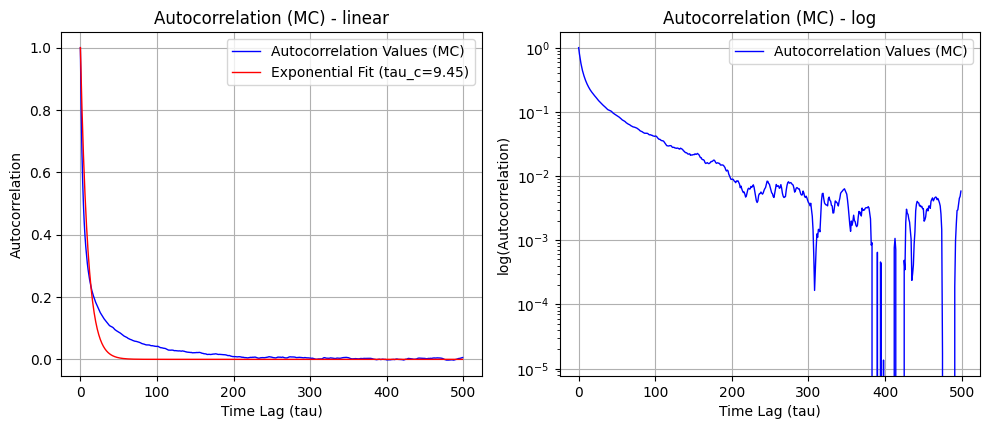

In [16]:
plt.figure(figsize=(10, 12))

plt.subplot(3, 2, 1)
plt.plot(tau, autocorr_values, color='blue', linewidth=1, label="Autocorrelation Values (MC)")
plt.plot(tau, exponential_decay(tau, tau_c), color='red', linewidth=1, label=f"Exponential Fit (tau_c={tau_c:.2f})")
plt.xlabel("Time Lag (tau)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation (MC) - linear")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(tau, autocorr_values, color='blue', linewidth=1, label="Autocorrelation Values (MC)")
#plt.plot(tau, exponential_decay(tau, tau_c), color='red', linewidth=1, label=f"Exponential Fit (tau_c={tau_c:.2f})")
plt.yscale('log')
plt.xlabel("Time Lag (tau)")
plt.ylabel("log(Autocorrelation)")
plt.title("Autocorrelation (MC) - log")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

As in the MD case, a simple exponential fit is inadequate to capture the decay due to the highly complex, many-body nature of the Lennard-Jones fluid. However, because the Monte Carlo algorithm is fundamentally a stochastic Markov Chain process, its autocorrelation tail exhibits pure statistical noise fluctuating randomly around zero. This is in stark contrast to the structured, weakly oscillating tail produced by the deterministic Molecular Dynamics algorithm. 

Consequently, in this case, I can safely conclude that after $\sim 500$ steps the system is genuinely uncorrelated.


The autocorrelation study was a necessary preliminary step to determine the appropriate block length needed to collect independent block averages, which is essential for computing a reliable statistical uncertainty.

## Statistical Uncertainty and Block Size

To investigate how the estimated statistical uncertainty depends on the block size $L$, I took the previously collected instantaneous data and applied the Data Blocking technique using increasingly larger blocks. Specifically, I divided the fixed dataset into $N$ blocks of length $L$, computed the mean within each block, and then evaluated the final statistical uncertainty using the means across all $N$ blocks.

The statistical uncertainty, which is the standard error of the mean, is based on the variance of the block averages. The variance $\sigma^2_A$ is estimated as:
$$\sigma^2_A \simeq \langle A^2 \rangle - \langle A \rangle^2$$

To obtain these quantities, one averages the results derived from each of the $N$ blocks:
$$\langle A^2 \rangle \simeq \frac{1}{N} \sum_{i=1}^N A^2_i \quad \text{and} \quad \langle A\rangle^2 \simeq \left( \frac{1}{N} \sum_{i=1}^N A_i \right)^2$$

Finally, the statistical uncertainty of the mean computed with $N$ independent blocks is evaluated as:
$$\frac{\sigma_A}{\sqrt{N-1}} \simeq \sqrt{\frac{1}{N-1} \left[ \frac{1}{N} \sum_{i=1}^N A^2_i - \left( \frac{1}{N} \sum_{i=1}^N A_i \right)^2 \right]} $$

What I observe for both Molecular Dynamics and Monte Carlo is that the estimated uncertainty is severely underestimated when using small blocks. This happens because small blocks contain highly correlated measurements; as a result, the mean of one block is very close to the mean of the next one, leading to an artificially small variance. 

As the block length $L$ increases, the block averages become statistically independent, and the estimated uncertainty grows until it reaches a saturation plateau, representing the true statistical error of the simulation. However, since the total number of generated data points is fixed, increasing the block length necessarily decreases the total number of blocks $N$. This reduction in available statistics causes the estimated uncertainty to exhibit larger fluctuations at very large block sizes.

In [17]:
def data_blocking_error(data, L):
    # Number of full blocks
    N = len(data) // L
    
    if N <= 1:
        return 0.0 # Only one block no uncertainty
    
    # Truncate the data array to make it the length of a multiple of L
    data_truncated = data[:N*L]
    
    # Data reorganized in a matrix of N rows and L columns
    # Each row is a block
    blocks = data_truncated.reshape(N, L)
    
    # Block mean: sum along the row (the column index shifts)
    block_means = np.mean(blocks, axis=1)
    
    # Mean of all the blocks
    global_mean = np.mean(block_means)

    # Mean of the squared means of each block
    global_mean_squared = np.mean(block_means**2)
    
    # Statistical error
    error = np.sqrt((global_mean_squared - global_mean**2) / (N - 1))
    
    return error

In [18]:
# Choose the block lengths to test 
L_values = np.arange(10, 5001, 10) 

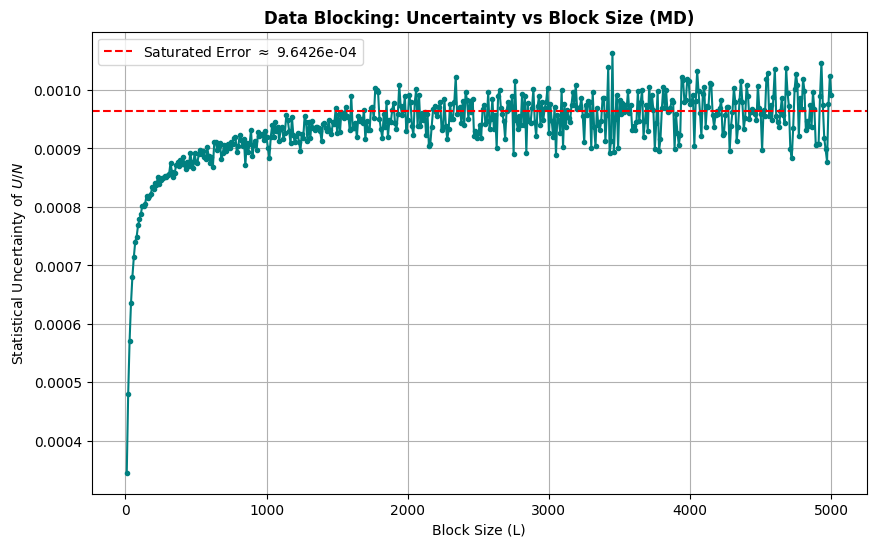

In [19]:
# ==========================================
# MOLECULAR DYNAMICS
# ==========================================

errors = [data_blocking_error(potential_energy_MD, L) for L in L_values]


plt.figure(figsize=(10, 6))
plt.plot(L_values, errors, marker='o', markersize=3, linestyle='-', color='teal')
plt.xlabel("Block Size (L)")
plt.ylabel("Statistical Uncertainty of $U/N$")
plt.title("Data Blocking: Uncertainty vs Block Size (MD)", fontweight='bold')
plt.grid(True)

saturated_error = np.mean(errors[-50:])
plt.axhline(saturated_error, color='red', linestyle='--', label=f'Saturated Error $\\approx$ {saturated_error:.4e}')

plt.legend()
plt.show()

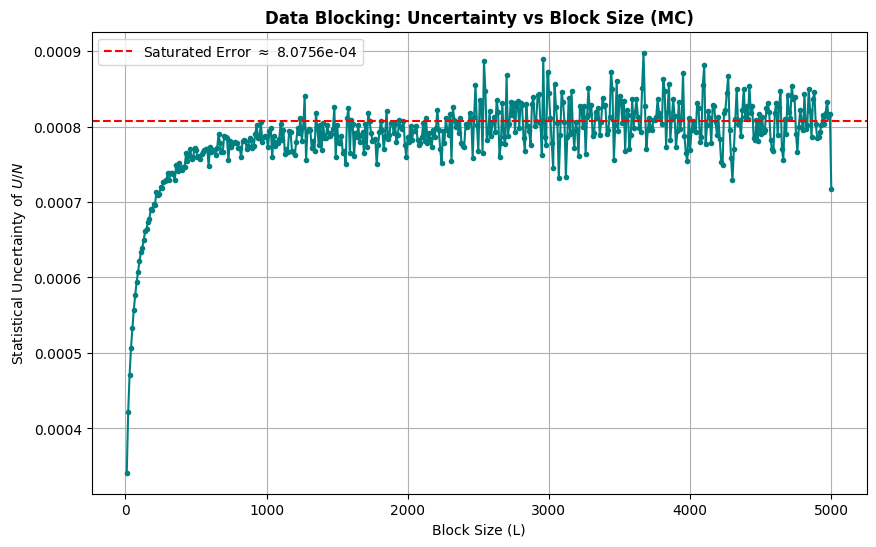

In [20]:
# ==========================================
# MONTECARLO
# ==========================================

errors = [data_blocking_error(potential_energy_MC, L) for L in L_values]

plt.figure(figsize=(10, 6))
plt.plot(L_values, errors, marker='o', markersize=3, linestyle='-', color='teal')
plt.xlabel("Block Size (L)")
plt.ylabel("Statistical Uncertainty of $U/N$")
plt.title("Data Blocking: Uncertainty vs Block Size (MC)", fontweight='bold')
plt.grid(True)

saturated_error = np.mean(errors[-50:])
plt.axhline(saturated_error, color='red', linestyle='--', label=f'Saturated Error $\\approx$ {saturated_error:.4e}')

plt.legend()
plt.show()

# Exercise 7.3

## Radial Distribution Function $g(r)$

A monoatomic fluid can be structurally characterized by specific distribution functions for the atomic positions. The simplest and most important of these is the radial distribution function, $g(r)$. It represents the probability density of finding two atoms at a distance $r$ apart, relative to the probability expected for a completely random distribution at the same density (i.e., an ideal gas).

In a system of $N$ particles with number density $\rho$, the exact microscopic expression for the radial distribution is:
$$g(\vec{r}) = \frac{1}{\rho N}\left<\sum_{i=1}^N \sum_{j=1, j\neq i}^N \delta\left[\vec{r} - \left(\vec{r}_i -\vec{r}_j\right)\right]\right>$$

For an isotropic fluid, this function depends only on the modulus of the distance $r$. We can report it as a function of $r$ by averaging over all solid angles:
$$g(r) = \langle g(\vec{r}) \rangle _{\substack{r \in [r, r+dr] \\ \theta \in [0, \pi] \\ \phi \in [0, 2\pi]}} = \frac{1}{\rho N \Delta V(r)} \left\langle \sum_{i=1}^N \sum_{j=1, j\neq i}^N \delta(|\vec{r}| - |\vec{r}_i - \vec{r}_j|) \right\rangle$$
where
$$\Delta V(r) = \frac{4\pi}{3} \left[ (r+dr)^3 - r^3 \right]$$
is the volume of the spherical shell between radius $r$ and $r+dr$. This geometric factor is crucial for normalization, since spherical shells at larger radii inherently contain more volume, and therefore a higher absolute probability of finding particles, regardless of the structural interactions. 

### Implementation

The numerical calculation is implemented by building an histogram of the distances. During the simulation, the distance between every possible pair of particles is calculated. If the distance falls within the $k$-th bin (corresponding to a specific radius shell), the counter for that bin is increased by $2$ (because both particles of the pair are mutually at distance $r$). At the end of a block, the accumulated histogram is normalized by dividing the bin counts by $\rho N \Delta V(r)$ to obtain the final $g(r)$.

# Exercise 7.4

## Thermodynamic and Structural Properties: Potential Energy, Pressure, and $g(r)$

Having determined the ideal block length required to obtain uncorrelated measurements and correctly estimate the statistical uncertainty, I now proceed to calculate the main physical properties of the Lennard-Jones liquid.

### Equilibration
To ensure the system is in the correct thermodynamic state for this specific run, I first performed a fresh equilibration phase. For both Molecular Dynamics and Monte Carlo, I ran an equilibration simulation of $10^4$ steps, recording the instantaneous temperature and potential energy for MD, and only the potential energy and progressive acceptance for MC as described above.

I report the plots of the quantititesto show equilibration.

In [21]:
_, kinetic_energy_MD_eq4, _, _ = np.loadtxt(path_MD_eq4 + "kinetic_energy.dat", unpack=True)
_, temperature_MD_eq4, _, _ = np.loadtxt(path_MD_eq4 + "temperature.dat", unpack=True)
_, potential_energy_MD_eq4, _, _ = np.loadtxt(path_MD_eq4 + "potential_energy.dat", unpack=True)

_, acceptance_MC_eq4 = np.loadtxt(path_MC_eq4 + "acceptance.dat", unpack=True)
_, potential_energy_MC_eq4, _, _ = np.loadtxt(path_MC_eq4 + "potential_energy.dat", unpack=True)

Equilibrium temperature T* = 1.1


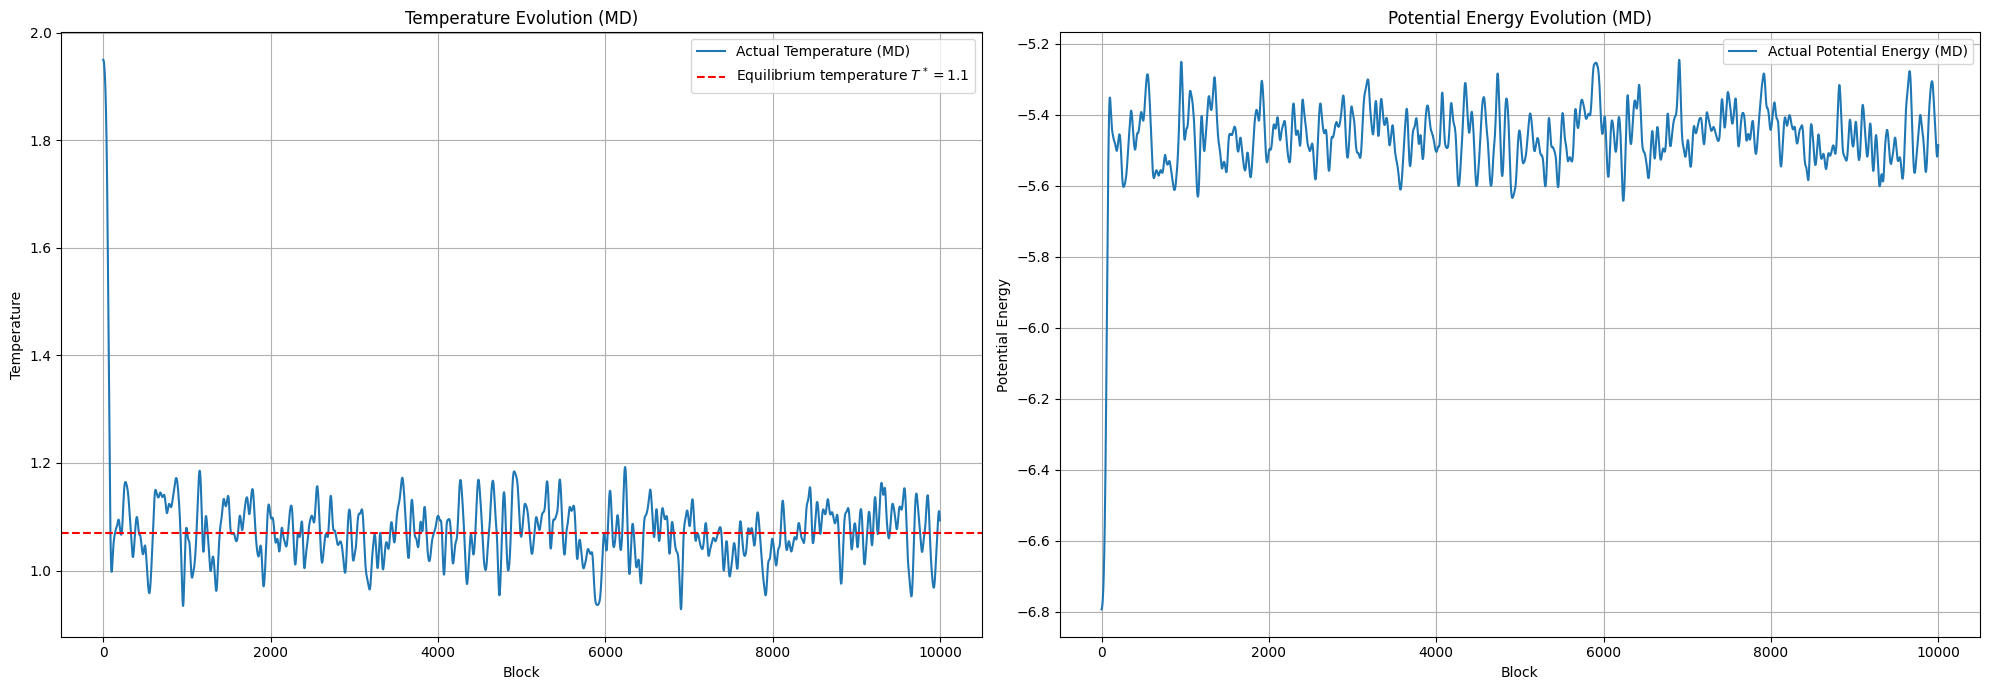

In [22]:
# ==========================================
# MOLECULAR DYNAMICS - EQUILIBRATION
# ==========================================

equilibrium_T = np.mean(temperature_MD_eq4[-6000:])
print(f"Equilibrium temperature T* = {equilibrium_T:.1f}")

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(temperature_MD_eq4, label="Actual Temperature (MD)")
axs[0].axhline(equilibrium_T, c='red', linestyle='--', label=f'Equilibrium temperature $T^* = ${equilibrium_T:.1f}')
axs[0].set_xlabel("Block")
axs[0].set_ylabel("Temperature")
axs[0].set_title("Temperature Evolution (MD)")
axs[0].legend()
axs[0].grid()

axs[1].plot(potential_energy_MD_eq4, label="Actual Potential Energy (MD)")
axs[1].set_xlabel("Block")
axs[1].set_ylabel("Potential Energy")
axs[1].set_title("Potential Energy Evolution (MD)")
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

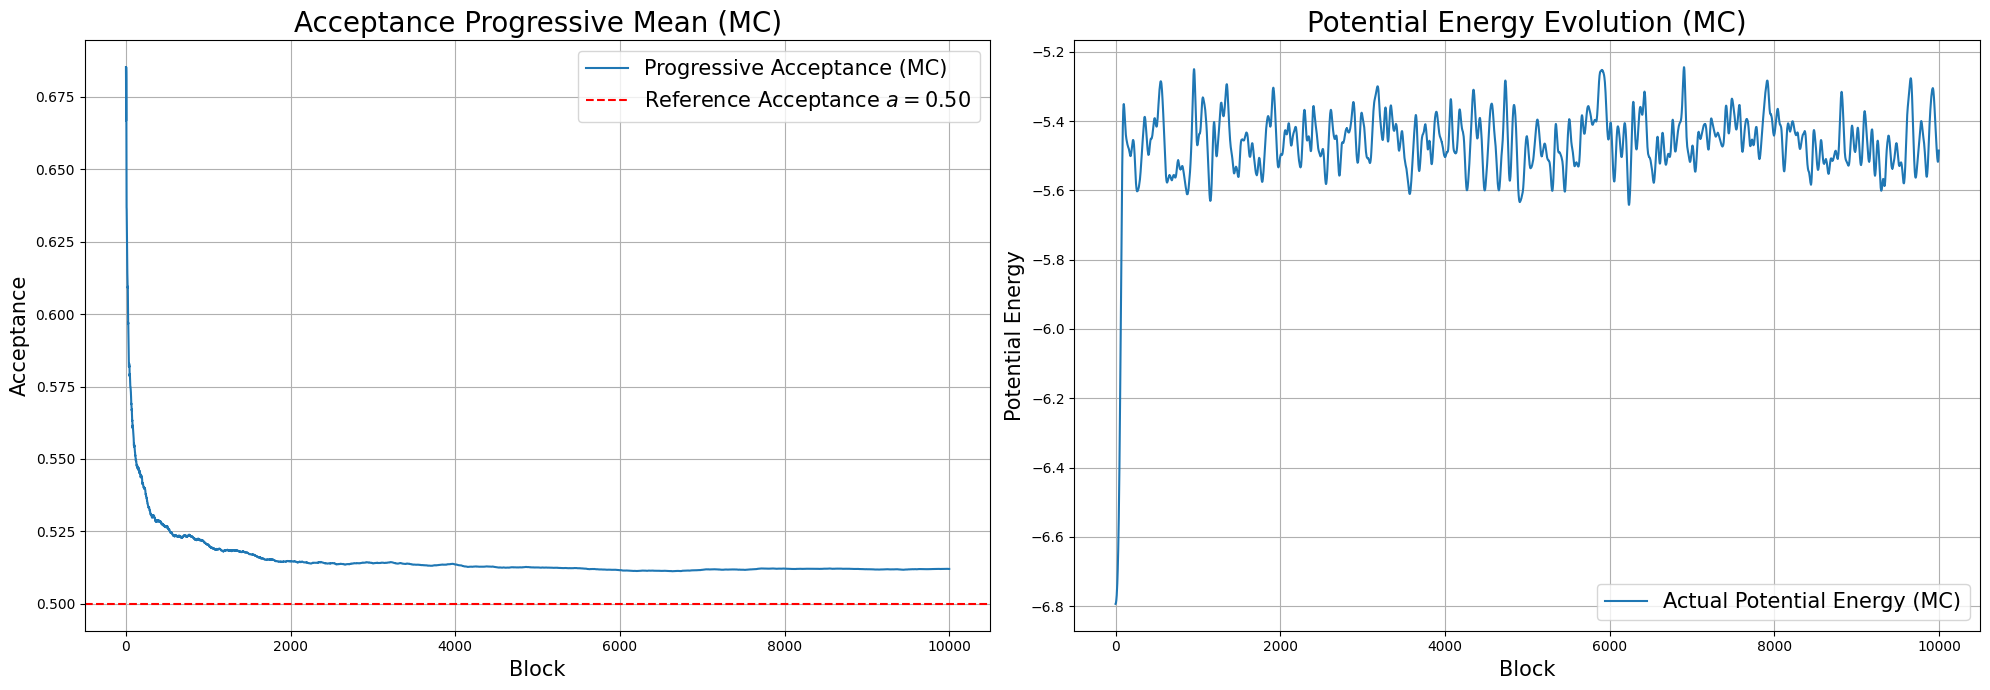

In [23]:
# ==========================================
# MONTECARLO - EQUILIBRATION
# ==========================================

reference_a = 0.50

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(acceptance_MC_eq4, label="Progressive Acceptance (MC)")
axs[0].axhline(reference_a, c='red', linestyle='--', label=f'Reference Acceptance $a = ${reference_a:.2f}')
axs[0].set_xlabel("Block", fontsize=15)
axs[0].set_ylabel("Acceptance", fontsize=15)
axs[0].set_title("Acceptance Progressive Mean (MC)", fontsize=20)
axs[0].legend(fontsize=15)
axs[0].grid()

axs[1].plot(potential_energy_MD_eq4, label="Actual Potential Energy (MC)")
axs[1].set_xlabel("Block", fontsize=15)
axs[1].set_ylabel("Potential Energy", fontsize=15)
axs[1].set_title("Potential Energy Evolution (MC)", fontsize=20)
axs[1].legend(fontsize=15)
axs[1].grid()

plt.tight_layout()
plt.show()

### Final Results and Ensembles Comparison

In the following plots, I first present the progressive averages of the potential energy per particle and the pressure, obtained through Molecular Dynamics and Monte Carlo simulations respectively. 

Subsequently, I show the final estimation of the radial distribution function $g(r)$, with the MD and MC results superimposed. This final curve represents the cumulative average over all blocks, complete with its statistical uncertainty evaluated at the final step of the Data Blocking procedure. In the adjacent panel to the right, I plot the exact difference between the two $g(r)$ curves to better visualize any discrepancies relative to the scale of the statistical uncertainties.

To guarantee that the block averages are completely statistically independent, as determined by the previous autocorrelation analysis, I ran both simulations using $40$ blocks of $20000$ steps each. To ensure that the measurement were taken on equilibrated system, I restarted both simulation from the last configuration of the respective equilibration run.

What we would like to demonstrate here is a fundamental principle of statistical mechanics: in the thermodynamic limit ($N \to \infty$), the microcanonical ensemble (NVE, simulated via Molecular Dynamics) and the canonical ensemble (NVT, simulated via Monte Carlo) are strictly equivalent. Despite the entirely different approaches to exploring phase space, they give rise to the exact same macroscopic thermodynamic and structural properties.

In [24]:
blk_md, epot_md, err_epot_md = np.loadtxt(path_MD4 + "potential_energy.dat", usecols=(0, 2, 3), unpack=True)
blk_mc, epot_mc, err_epot_mc = np.loadtxt(path_MC4 + "potential_energy.dat", usecols=(0, 2, 3), unpack=True)

blk_mc, pres_mc, err_pres_mc = np.loadtxt(path_MC4 + "pressure.dat", usecols=(0, 2, 3), unpack=True)
blk_md, pres_md, err_pres_md = np.loadtxt(path_MD4 + "pressure.dat", usecols=(0, 2, 3), unpack=True)

r, gofr_mc, err_gofr_mc = np.loadtxt(path_MC4 + "gofr.dat", usecols=(0, 1, 2), unpack=True)
r, gofr_md, err_gofr_md = np.loadtxt(path_MD4 + "gofr.dat", usecols=(0, 1, 2), unpack=True)

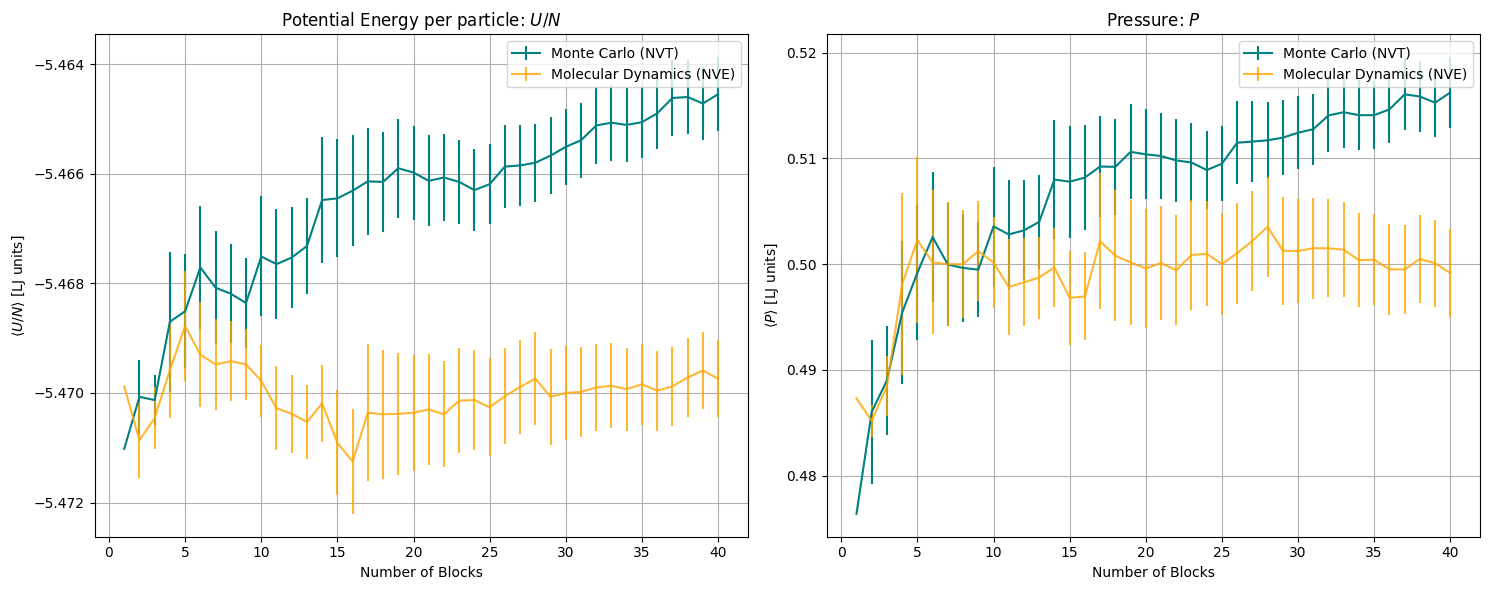

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Potential Energy
ax1.errorbar(blk_mc, epot_mc, yerr=err_epot_mc, label="Monte Carlo (NVT)", color='teal')
ax1.errorbar(blk_md, epot_md, yerr=err_epot_md, label="Molecular Dynamics (NVE)", color='orange', alpha=0.8)
ax1.set_title("Potential Energy per particle: $U/N$")
ax1.set_xlabel("Number of Blocks")
ax1.set_ylabel("$\\langle U/N \\rangle$ [LJ units]")
ax1.grid(True)
ax1.legend()

# Pressure
ax2.errorbar(blk_mc, pres_mc, yerr=err_pres_mc, label="Monte Carlo (NVT)", color='teal')
ax2.errorbar(blk_md, pres_md, yerr=err_pres_md, label="Molecular Dynamics (NVE)", color='orange', alpha=0.8)
ax2.set_title("Pressure: $P$")
ax2.set_xlabel("Number of Blocks")
ax2.set_ylabel("$\\langle P \\rangle$ [LJ units]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

Looking at the plots, we can observe a slight, systematic discrepancy between the two methods, particularly in the pressure and potential energy. This divergence is not an error in the algorithms, but rather a well-known consequence of two factors:
1. **Finite-Size Effects:** Our system is extremely small ($N=108$). At this scale, the theoretical equivalence of ensembles is not exact, and boundary/fluctuation effects become visible.
2. **Temperature Mismatch:** In the MC simulation, the temperature is strictly fixed at $T^\star = 1.1$ by the Metropolis weight. In the MD simulation, the target equilibrium temperature is achieved empirically. If the final equilibrated temperature of the NVE run differs even slightly from exactly $1.1$, it naturally leads to a small offset in the measured energy and pressure compared to the NVT results.

Despite these microscopic differences, the overall structural agreement (as will be seen in the $g(r)$ in the plot below) and the proximity of the thermodynamic values confirm that both algorithms are correctly simulating the liquid phase of Argon.

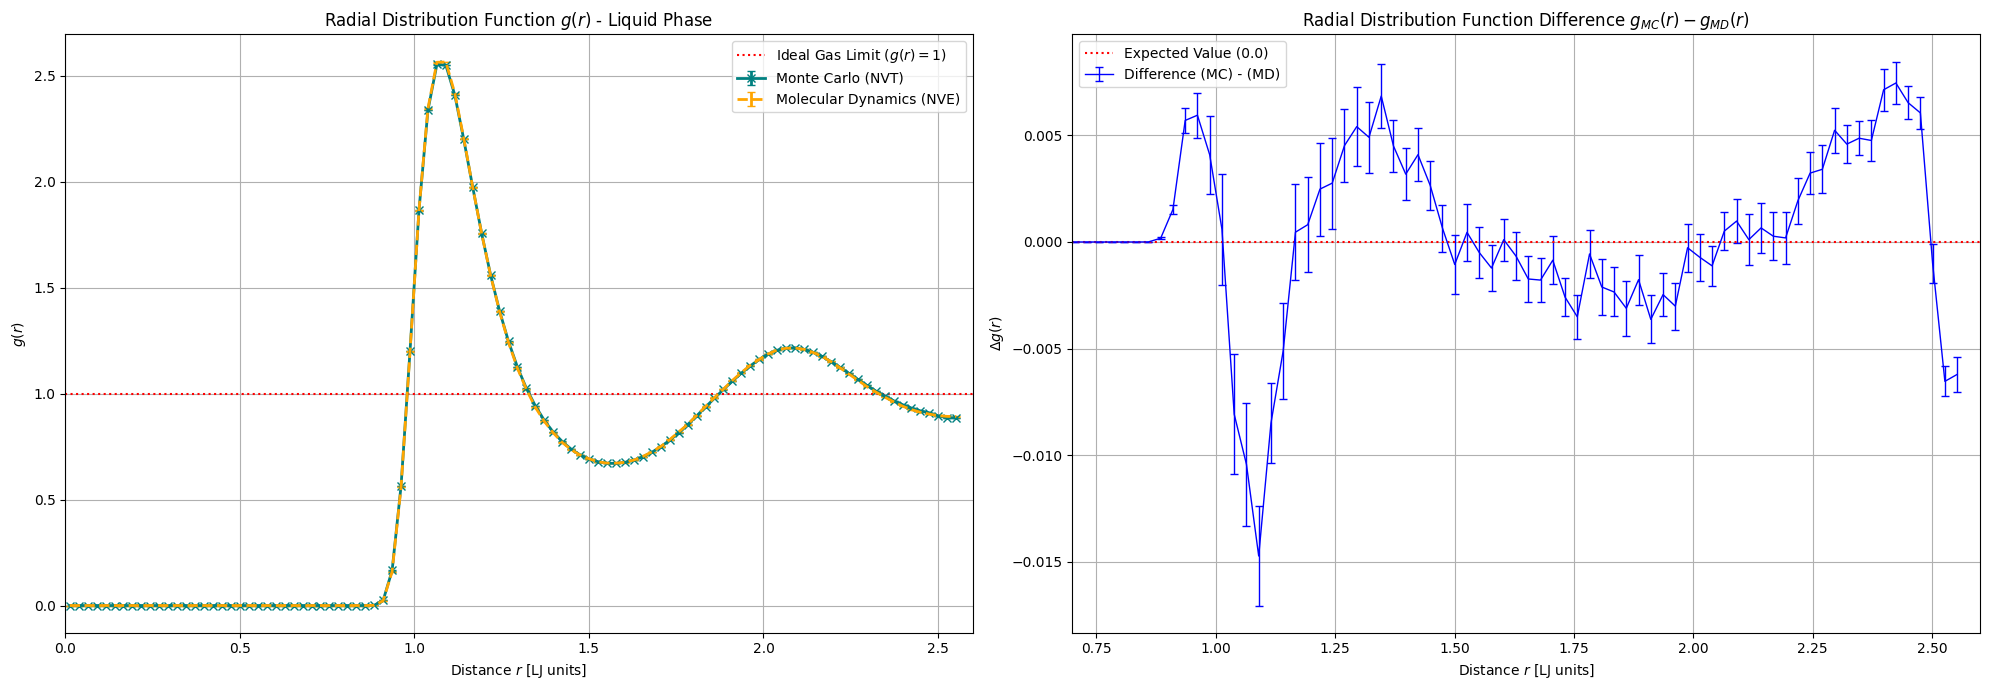

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Left plot: Radial distribution function g(r)
ax1.errorbar(r, gofr_mc, yerr=err_gofr_mc, fmt='-x', capsize=3, color='teal', linewidth=2, label="Monte Carlo (NVT)")
ax1.errorbar(r, gofr_md, yerr=err_gofr_md, capsize=3, color='orange', linewidth=2, linestyle='--', label="Molecular Dynamics (NVE)")
ax1.axhline(1.0, color='red', linestyle=':', label="Ideal Gas Limit ($g(r)=1$)")

ax1.set_title("Radial Distribution Function $g(r)$ - Liquid Phase")
ax1.set_xlabel("Distance $r$ [LJ units]")
ax1.set_ylabel("$g(r)$")
ax1.set_xlim(0, 2.6)
ax1.grid(True)
ax1.legend()

# Right plot: Absolute difference
diff_err = np.sqrt(err_gofr_mc**2 + err_gofr_md**2)
ax2.errorbar(r, gofr_mc - gofr_md, yerr=diff_err, fmt='-', capsize=3, color='blue', linewidth=1, label="Difference (MC) - (MD)")
ax2.axhline(0.0, color='red', linestyle=':', label="Expected Value (0.0)")

ax2.set_title("Radial Distribution Function Difference $g_{MC}(r) - g_{MD}(r)$")
ax2.set_xlabel("Distance $r$ [LJ units]")
ax2.set_ylabel("$\Delta g(r)$")
ax2.set_xlim(0.7, 2.6)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

Finally, I present the results for the radial distribution function $g(r)$, which characterizes the microscopic spatial structure of the simulated fluid. The left panel displays the final cumulative average of $g(r)$ for both Monte Carlo and Molecular Dynamics, while the right panel highlights the absolute difference between the two curves, $\Delta g(r) = g_{MC}(r) - g_{MD}(r)$, complete with its propagated statistical uncertainty.

As expected for a system in the liquid phase, the $g(r)$ profile exhibits a sharp primary peak, representing the first coordination shell of particles, followed by damped oscillations that progressively converge to the ideal gas limit ($g(r) \approx 1$) at larger distances, indicating the loss of long-range order. On a macroscopic scale, the two distributions appear perfectly superimposable.

However, looking closely at the difference plot, we can observe that the discrepancy $\Delta g(r)$, although extremely small (on the order of $10^{-2}$), is not purely random statistical noise. It exhibits a structured behavior and in several regions—particularly around the first coordination peak—it clearly exceeds the statistical error bars. 

This structured discrepancy perfectly mirrors what we observed in the potential energy and pressure plots. Because the Molecular Dynamics simulation (NVE) reached an empirical equilibrium temperature that is likely slightly different from the strictly fixed $T^\star = 1.1$ of the Monte Carlo simulation (NVT), the two finite-size systems are not in an identical thermodynamic state. A slight mismatch in temperature naturally translates into minute differences in the height and width of the structural peaks. 